# P(white plays Rb5 with ≤M material on the board)

For each material threshold M (total of both sides, kings excluded, standard piece values P=1 N=B=3 R=5 Q=9), what fraction of games have seen white move a rook to b5 at a moment when total material was ≤M?

Material decreases monotonically, so we record the *minimum* material at any white-Rb5 in each game — equivalent to: does this game have a white-Rb5 in the material ≤M phase?

Toggle `USE_FULL_CORPUS` to switch between the 100-game sample (instant) and the full ~900k-game corpus (~2 min on 8 cores).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from chess_corpus.analysis import map_shards, white_rook_to_b5

USE_FULL_CORPUS = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SHARD_DIR = ROOT / ("data/processed/games" if USE_FULL_CORPUS else "data/sample/games")
print(f"Reading shards from {SHARD_DIR}")

Reading shards from /Users/paul/pwsiegel/chess-move-stats/data/sample/games


In [2]:
per_game = pd.DataFrame(map_shards(white_rook_to_b5, shard_dir=SHARD_DIR))
print(f"games scanned: {len(per_game):,}")
print(f"games with white Rb5: {per_game['first_rb5_fullmove'].notna().sum():,}")
per_game[per_game['min_material_at_rb5'].notna()].head()

games scanned: 100
games with white Rb5: 4


,first_rb5_fullmove,min_material_at_rb5,n_white_moves
34,16.0,40.0,34
49,26.0,42.0,30
50,26.0,42.0,31
93,31.0,36.0,51


## Build the CDF: P(Rb5 with ≤M material at the time)

Initial material is 78 (both sides have 8P + 2N + 2B + 2R + Q = 39). We sweep M from 0 to 78.

Note this is a *joint* probability: P(game has a white-Rb5 AND material was ≤M at that moment). The full curve reaches the unconditional P(any white Rb5) at M=78.

In [3]:
n_total = len(per_game)
min_mat = per_game["min_material_at_rb5"].dropna().astype(int).values

ms = np.arange(0, 79)
counts = np.array([(min_mat <= m).sum() for m in ms])
cdf = pd.DataFrame({"M": ms, "games_with_rb5_at_<=M": counts, "prob": counts / n_total})
cdf.iloc[::8]  # every 8th row

,M,games_with_rb5_at_<=M,prob
0,0,0,0.00
8,8,0,0.00
16,16,0,0.00
24,24,0,0.00
32,32,0,0.00
40,40,2,0.02
48,48,4,0.04
56,56,4,0.04
64,64,4,0.04
72,72,4,0.04


## Plot

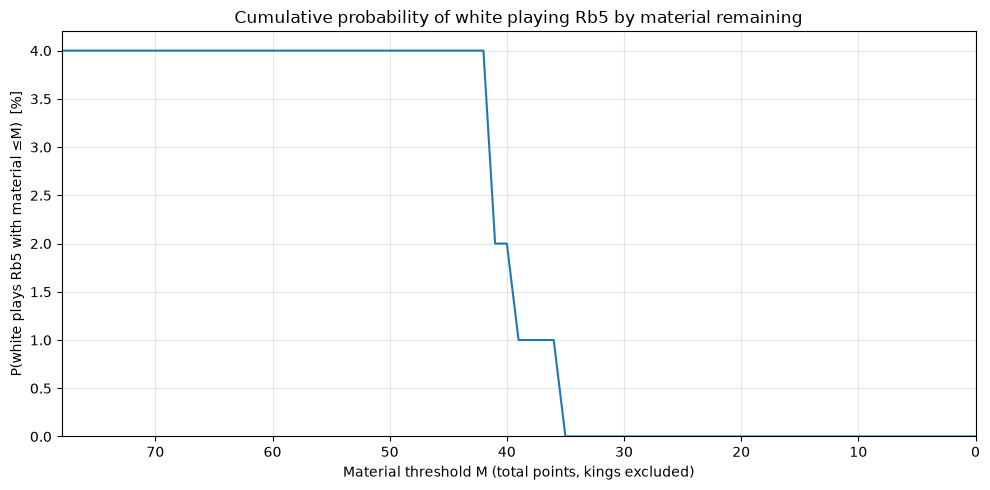

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf["M"], cdf["prob"] * 100)
ax.set_xlabel("Material threshold M (total points, kings excluded)")
ax.set_ylabel("P(white plays Rb5 with material ≤M)  [%]")
ax.set_title("Cumulative probability of white playing Rb5 by material remaining")
ax.set_xlim(0, 78)
ax.invert_xaxis()  # left = late endgame, right = opening
ax.grid(alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()